# EfficientNet-B2 – Multi-Label Apparel Classification

## Task 3.1 – Multi-Label Classification

This notebook implements:

- EfficientNet-B2 (Fine-Tuning)
- EfficientNet-B2 (Training from Scratch)
- EfficientNet-B2 (Transfer Learning — frozen backbone)

Dataset:
- DeepFashion2 (Top-5 categories pruned)

Loss:
- BCEWithLogitsLoss (multi-label)

Evaluation:
- Per-class Precision, Recall, F1
- Macro F1 / Micro F1
- ROC-AUC per class

Model checkpoints are saved to `/kaggle/working/` after every improvement so that
**even if the Kaggle session restarts the best weights are preserved.**

In [1]:
# ===============================
#  Imports
# ===============================

import os
import copy
import random
import torch
import torch.nn as nn
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torch.amp import GradScaler, autocast

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm import tqdm

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ===============================
#  CONFIG
# ===============================

MODEL_VARIANT = 'b2'   # fixed for this notebook
IMG_SIZE      = 260    # EfficientNet-B2 recommended input size

EPOCHS      = 8
BATCH_SIZE  = 16   # B2 is larger than B0 — use 16 to stay safe on T4
NUM_WORKERS = 4
SEED        = 42

# ===============================
#  Reproducibility
# ===============================

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.benchmark = True

# ===============================
#  Device
# ===============================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device    :', device)
print('Model variant   : EfficientNet-B2')
print('Input resolution:', IMG_SIZE, 'x', IMG_SIZE)
print('Batch size      :', BATCH_SIZE)

Using device    : cuda
Model variant   : EfficientNet-B2
Input resolution: 260 x 260
Batch size      : 16


## Step 1: Load Preprocessed Data

We load:
- `train_samples`
- `val_samples`
- `pos_weights`
- `category_map`

These were generated in the preprocessing notebook.

In [2]:
# ===============================
#  Load Preprocessed Dataset
# ===============================

PREPROC_PATH = '/kaggle/input/datasets/harshitabansal307/deepfashion-classification-preprocessed'

train_samples = torch.load(os.path.join(PREPROC_PATH, 'train_samples.pt'), map_location='cpu')
val_samples   = torch.load(os.path.join(PREPROC_PATH, 'val_samples.pt'),   map_location='cpu')
pos_weights   = torch.load(os.path.join(PREPROC_PATH, 'pos_weights.pt'),   map_location='cpu')
category_map  = torch.load(os.path.join(PREPROC_PATH, 'category_map.pt'),  map_location='cpu')

pos_weights = pos_weights.to(device)

print('Train samples    :', len(train_samples))
print('Val   samples    :', len(val_samples))
print('Category map     :', category_map)
print('Pos-weight device:', pos_weights.device)

Train samples    : 144174
Val   samples    : 23741
Category map     : {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
Pos-weight device: cuda:0


## Step 2: Define Dataset Paths

In [3]:
# ===============================
#  Dataset Paths
# ===============================

DATASET_PATH  = '/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset'
TRAIN_IMG_DIR = os.path.join(DATASET_PATH, 'train',      'images')
VAL_IMG_DIR   = os.path.join(DATASET_PATH, 'validation', 'images')

print('Train image dir:', TRAIN_IMG_DIR)
print('Val   image dir:', VAL_IMG_DIR)

Train image dir: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/train/images
Val   image dir: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/validation/images


## Step 3: Image Transformations

EfficientNet-B2 uses **260×260** input resolution.

**Training:** RandomResizedCrop, horizontal flip, rotation, colour jitter, normalise  
**Validation:** Resize, normalise

In [4]:
# ===============================
#  Image Transformations
# ===============================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined for EfficientNet-B2 (260x260).')

Transforms defined for EfficientNet-B2 (260x260).


## Step 4: Custom Dataset Class

- Loads images dynamically (not pre-cached in memory)
- Returns image tensor + multi-label float tensor (size = 5)
- Graceful fallback for corrupt / missing images

In [5]:
# ===============================
#  Custom Dataset
# ===============================

class DeepFashionMultiLabelDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

## Step 5: Create Dataset Objects & DataLoaders

`WeightedRandomSampler` is used on the training set to handle class imbalance.

In [6]:
# ===============================
#  Datasets
# ===============================

train_dataset = DeepFashionMultiLabelDataset(train_samples, transform=train_transforms)
val_dataset   = DeepFashionMultiLabelDataset(val_samples,   transform=val_transforms)

print('Train dataset size:', len(train_dataset))
print('Val   dataset size:', len(val_dataset))

# ===============================
#  WeightedRandomSampler
# ===============================

sample_weights = [
    sum(pos_weights[i].item() * label[i] for i in range(len(label))) + 1e-6
    for _, label in train_samples
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ===============================
#  DataLoaders
# ===============================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f'DataLoaders ready — {len(train_loader)} train batches per epoch.')

# Quick sanity check
images, labels = next(iter(train_loader))
print('Batch image shape:', images.shape)
print('Batch label shape:', labels.shape)

Train dataset size: 144174
Val   dataset size: 23741
DataLoaders ready — 9011 train batches per epoch.
Batch image shape: torch.Size([16, 3, 260, 260])
Batch label shape: torch.Size([16, 5])


## Step 6: Build EfficientNet-B2 Model

A single factory function handles all three training strategies:

| Strategy | Pretrained | Frozen layers |
|---|---|---|
| `'finetune'` | ✅ ImageNet | None (all layers train) |
| `'transfer'` | ✅ ImageNet | All except classifier head |
| `'scratch'`  | ❌ | None (random init) |

In [7]:
# ===============================
#  EfficientNet-B2 Model Factory
# ===============================

NUM_CLASSES = len(category_map)

def build_efficientnet_b2(strategy: str):
    """
    strategy : 'finetune' | 'transfer' | 'scratch'
    """
    assert strategy in ('finetune', 'transfer', 'scratch'), \
        "strategy must be 'finetune', 'transfer', or 'scratch'"

    # ---------- weights ----------
    if strategy == 'scratch':
        weights = None
    else:
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1

    # ---------- backbone ----------
    model = models.efficientnet_b2(weights=weights)

    # ---------- freeze / unfreeze ----------
    if strategy == 'transfer':
        for param in model.parameters():
            param.requires_grad = False
    else:
        for param in model.parameters():
            param.requires_grad = True

    # ---------- replace classifier ----------
    # EfficientNet-B2 classifier head: model.classifier[1]
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

    # New head is always trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Xavier init for scratch
    if strategy == 'scratch':
        nn.init.xavier_uniform_(model.classifier[1].weight)
        nn.init.zeros_(model.classifier[1].bias)

    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  EfficientNet-B2 [{strategy}] — '
          f'trainable params: {trainable:,} / {total:,}')
    return model

print(f'NUM_CLASSES = {NUM_CLASSES}')

NUM_CLASSES = 5


## Step 7: Training & Validation Loop

Features:
- Mixed precision (`autocast` + `GradScaler`) for fine-tune & transfer
- Macro F1 tracked each epoch
- Best weights saved to disk **immediately** on every improvement — session-restart safe
- Returns full history for plotting

In [8]:
# ===============================
#  Train / Validate Loop
# ===============================

def train_model(model, strategy_label, save_path, use_amp=True):
    """
    Trains model for EPOCHS epochs.
    Saves best model (by val Macro F1) to save_path after every improvement.
    Returns (best_model, history_dict)
    """
    # Learning rate & weight decay by strategy
    lr = 1e-5 if strategy_label in ('finetune', 'transfer') else 1e-4
    wd = 1e-4  if strategy_label == 'scratch' else 0.0

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=wd
    )
    scaler = GradScaler('cuda') if (use_amp and device.type == 'cuda') else None

    best_macro_f1      = 0.0
    best_model_weights = None

    history = {
        'train_loss': [], 'val_loss': [],
        'macro_f1':   [], 'micro_f1': []
    }

    for epoch in range(EPOCHS):

        # -------- TRAIN --------
        model.train()
        running_train_loss = 0.0

        for images, labels in tqdm(train_loader,
                                   desc=f'[{strategy_label}] Epoch {epoch+1}/{EPOCHS}'):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            if scaler is not None:
                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # -------- VALIDATE --------
        model.eval()
        running_val_loss = 0.0
        all_labels, all_preds = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss    = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()
                all_labels.append(labels.cpu().numpy())
                all_preds.append(preds.cpu().numpy())

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)

        all_labels_np = np.vstack(all_labels)
        all_preds_np  = np.vstack(all_preds)

        macro_f1 = f1_score(all_labels_np, all_preds_np, average='macro',  zero_division=0)
        micro_f1 = f1_score(all_labels_np, all_preds_np, average='micro',  zero_division=0)
        history['macro_f1'].append(macro_f1)
        history['micro_f1'].append(micro_f1)

        print(f'\nEpoch [{epoch+1}/{EPOCHS}]')
        print(f'  Train Loss : {epoch_train_loss:.4f}')
        print(f'  Val   Loss : {epoch_val_loss:.4f}')
        print(f'  Macro F1   : {macro_f1:.4f}   Micro F1: {micro_f1:.4f}')

        # -------- CHECKPOINT --------
        if macro_f1 > best_macro_f1:
            best_macro_f1      = macro_f1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(f'  ✅ Best model saved → {save_path}  (Macro F1 = {best_macro_f1:.4f})')

    print(f'\nTraining complete [{strategy_label}]. Best Macro F1: {best_macro_f1:.4f}')
    model.load_state_dict(best_model_weights)
    return model, history

## Step 8: Evaluation Function

Computes and prints:
- Per-class Precision / Recall / F1 / AUC
- Overall Macro F1, Micro F1, Macro AUC
- ROC curve plot

In [9]:
# ===============================
#  Evaluation Function
# ===============================

def evaluate_model(model, data_loader, title=''):

    model.eval()
    all_labels, all_outputs = [], []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=f'Evaluating {title}'):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            all_labels.append(labels.cpu())
            all_outputs.append(outputs.cpu())

    all_labels_np  = torch.cat(all_labels).numpy()
    all_outputs_t  = torch.cat(all_outputs)
    probs          = torch.sigmoid(all_outputs_t).numpy()
    preds          = (probs > 0.5).astype(int)

    precision = precision_score(all_labels_np, preds, average=None, zero_division=0)
    recall    = recall_score   (all_labels_np, preds, average=None, zero_division=0)
    f1        = f1_score       (all_labels_np, preds, average=None, zero_division=0)

    macro_f1 = f1_score(all_labels_np, preds, average='macro', zero_division=0)
    micro_f1 = f1_score(all_labels_np, preds, average='micro', zero_division=0)

    try:
        roc_auc_per = roc_auc_score(all_labels_np, probs, average=None)
        macro_auc   = roc_auc_score(all_labels_np, probs, average='macro')
    except Exception:
        roc_auc_per = [0] * NUM_CLASSES
        macro_auc   = 0.0

    ordered_classes = list(category_map.values())

    print(f'\n===== Per-Class Metrics — {title} =====')
    for i in range(NUM_CLASSES):
        print(f'\nClass: {ordered_classes[i]}')
        print(f'  Precision: {precision[i]:.4f}')
        print(f'  Recall   : {recall[i]:.4f}')
        print(f'  F1-score : {f1[i]:.4f}')
        print(f'  AUC      : {roc_auc_per[i]:.4f}')

    print(f'\n===== Overall Metrics — {title} =====')
    print(f'  Macro F1  : {macro_f1:.4f}')
    print(f'  Micro F1  : {micro_f1:.4f}')
    print(f'  Macro AUC : {macro_auc:.4f}')

    # ROC curves
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(ordered_classes):
        fpr, tpr, _ = roc_curve(all_labels_np[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {cls} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return macro_f1, micro_f1

## Step 9: Plot Training Curves

In [10]:
# ===============================
#  Plot Training History
# ===============================

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'],   label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history['macro_f1'], label='Macro F1')
    axes[1].plot(history['micro_f1'], label='Micro F1')
    axes[1].set_title(f'{title} — F1 Score')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

---
# ▶ TRAINING 1 of 3 — Fine-Tuning

- Pretrained ImageNet weights
- **All layers** trainable
- LR = 1e-5
- Mixed precision enabled

In [11]:
# ===============================
#  Fine-Tuning
# ===============================

FINETUNE_SAVE = '/kaggle/working/efficientnet_b2_best_finetune.pth'

print('--- Building EfficientNet-B2 (fine-tune) ---')
model_finetune = build_efficientnet_b2('finetune')

print(f'--- Training (fine-tune) for {EPOCHS} epochs ---')
model_finetune, history_finetune = train_model(
    model_finetune,
    strategy_label='finetune',
    save_path=FINETUNE_SAVE,
    use_amp=True
)

--- Building EfficientNet-B2 (fine-tune) ---
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 162MB/s] 


  EfficientNet-B2 [finetune] — trainable params: 7,708,039 / 7,708,039
--- Training (fine-tune) for 8 epochs ---


[finetune] Epoch 1/8: 100%|██████████| 9011/9011 [18:31<00:00,  8.10it/s] 



Epoch [1/8]
  Train Loss : 0.6345
  Val   Loss : 0.4305
  Macro F1   : 0.7742   Micro F1: 0.7904
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_finetune.pth  (Macro F1 = 0.7742)


...


Epoch [6/8]
  Train Loss : 0.3028
  Val   Loss : 0.3086
  Macro F1   : 0.8445   Micro F1: 0.8597
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_finetune.pth  (Macro F1 = 0.8445)


[finetune] Epoch 7/8: 100%|██████████| 9011/9011 [16:35<00:00,  9.06it/s]



Epoch [7/8]
  Train Loss : 0.2818
  Val   Loss : 0.3121
  Macro F1   : 0.8379   Micro F1: 0.8534


[finetune] Epoch 8/8: 100%|██████████| 9011/9011 [16:34<00:00,  9.06it/s]



Epoch [8/8]
  Train Loss : 0.2637
  Val   Loss : 0.3062
  Macro F1   : 0.8485   Micro F1: 0.8639
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_finetune.pth  (Macro F1 = 0.8485)

Training complete [finetune]. Best Macro F1: 0.8485


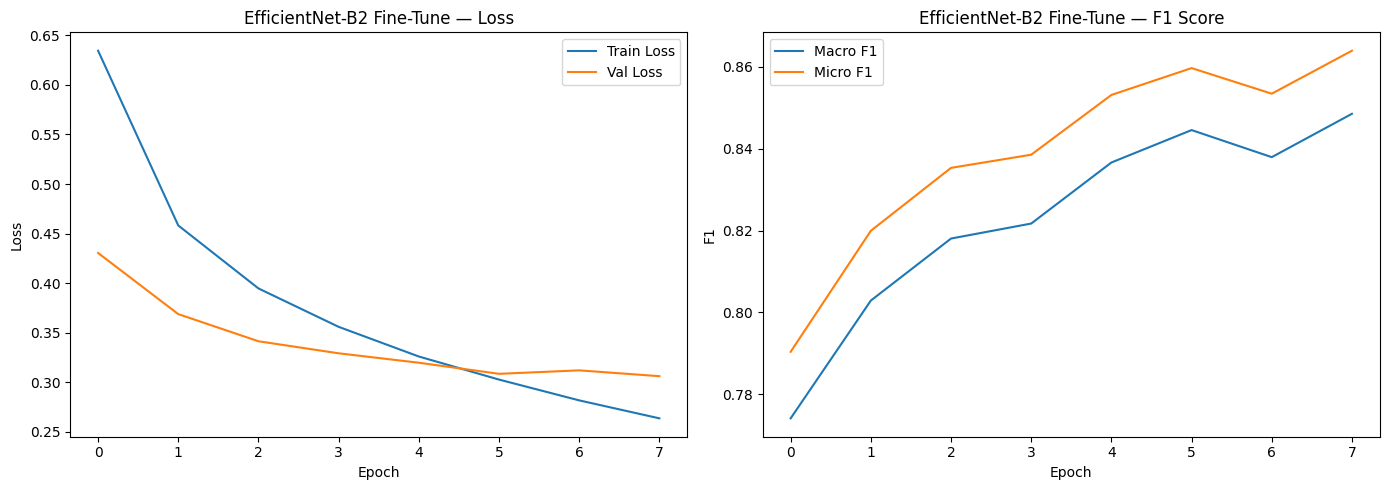

In [12]:
plot_history(history_finetune, 'EfficientNet-B2 Fine-Tune')


===== EfficientNet-B2 Fine-Tune — Validation Evaluation =====


Evaluating EfficientNet-B2 Fine-Tune: 100%|██████████| 1484/1484 [01:31<00:00, 16.18it/s]



===== Per-Class Metrics — EfficientNet-B2 Fine-Tune =====

Class: 0
  Precision: 0.8817
  Recall   : 0.9172
  F1-score : 0.8991
  AUC      : 0.9615

Class: 1
  Precision: 0.8607
  Recall   : 0.9580
  F1-score : 0.9067
  AUC      : 0.9820

Class: 2
  Precision: 0.6764
  Recall   : 0.9056
  F1-score : 0.7744
  AUC      : 0.9708

Class: 3
  Precision: 0.7191
  Recall   : 0.9101
  F1-score : 0.8034
  AUC      : 0.9595

Class: 4
  Precision: 0.7924
  Recall   : 0.9377
  F1-score : 0.8589
  AUC      : 0.9750

===== Overall Metrics — EfficientNet-B2 Fine-Tune =====
  Macro F1  : 0.8485
  Micro F1  : 0.8639
  Macro AUC : 0.9698


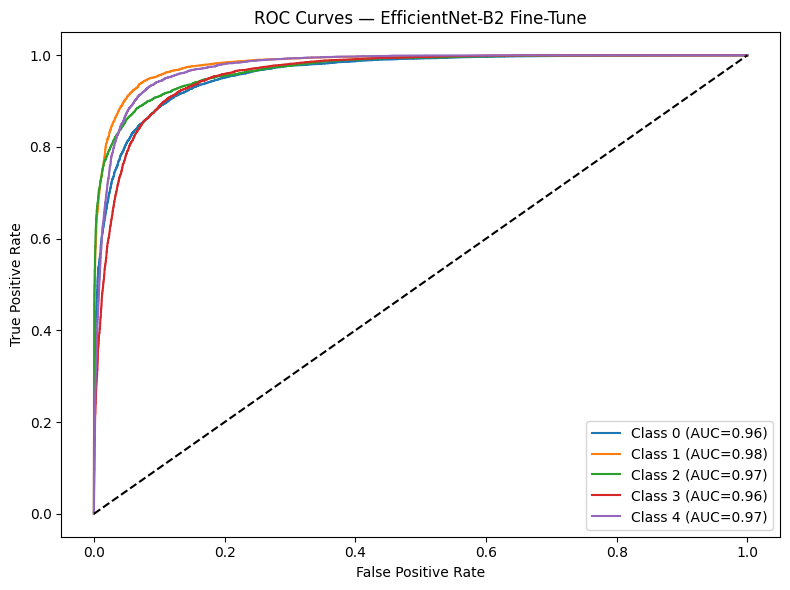

Final — Macro F1: 0.8485  |  Micro F1: 0.8639


In [13]:
print('\n===== EfficientNet-B2 Fine-Tune — Validation Evaluation =====')
macro_f1_ft, micro_f1_ft = evaluate_model(
    model_finetune, val_loader,
    title='EfficientNet-B2 Fine-Tune'
)
print(f'Final — Macro F1: {macro_f1_ft:.4f}  |  Micro F1: {micro_f1_ft:.4f}')

---
# ▶ TRAINING 2 of 3 — From Scratch

- **No pretrained weights** (random initialisation)
- All layers trainable
- LR = 1e-4, weight-decay = 1e-4
- Mixed precision enabled

In [14]:
# ===============================
#  Training from Scratch
# ===============================

SCRATCH_SAVE = '/kaggle/working/efficientnet_b2_best_scratch.pth'

print('--- Building EfficientNet-B2 (scratch) ---')
model_scratch = build_efficientnet_b2('scratch')

print(f'--- Training (scratch) for {EPOCHS} epochs ---')
model_scratch, history_scratch = train_model(
    model_scratch,
    strategy_label='scratch',
    save_path=SCRATCH_SAVE,
    use_amp=True
)

--- Building EfficientNet-B2 (scratch) ---
  EfficientNet-B2 [scratch] — trainable params: 7,708,039 / 7,708,039
--- Training (scratch) for 8 epochs ---


[scratch] Epoch 1/8: 100%|██████████| 9011/9011 [16:46<00:00,  8.95it/s]



Epoch [1/8]
  Train Loss : 0.9489
  Val   Loss : 0.8085
  Macro F1   : 0.5430   Micro F1: 0.5393
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_scratch.pth  (Macro F1 = 0.5430)


[scratch] Epoch 2/8: 100%|██████████| 9011/9011 [16:53<00:00,  8.89it/s]



Epoch [2/8]
  Train Loss : 0.7950
  Val   Loss : 0.6906
  Macro F1   : 0.6265   Micro F1: 0.6417
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_scratch.pth  (Macro F1 = 0.6265)


...


Epoch [6/8]
  Train Loss : 0.5724
  Val   Loss : 0.5332
  Macro F1   : 0.7121   Micro F1: 0.7240
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_scratch.pth  (Macro F1 = 0.7121)


[scratch] Epoch 7/8: 100%|██████████| 9011/9011 [16:40<00:00,  9.00it/s]



Epoch [7/8]
  Train Loss : 0.5485
  Val   Loss : 0.4861
  Macro F1   : 0.7408   Micro F1: 0.7563
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_scratch.pth  (Macro F1 = 0.7408)


[scratch] Epoch 8/8: 100%|██████████| 9011/9011 [16:43<00:00,  8.98it/s]



Epoch [8/8]
  Train Loss : 0.5290
  Val   Loss : 0.4766
  Macro F1   : 0.7450   Micro F1: 0.7619
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_scratch.pth  (Macro F1 = 0.7450)

Training complete [scratch]. Best Macro F1: 0.7450


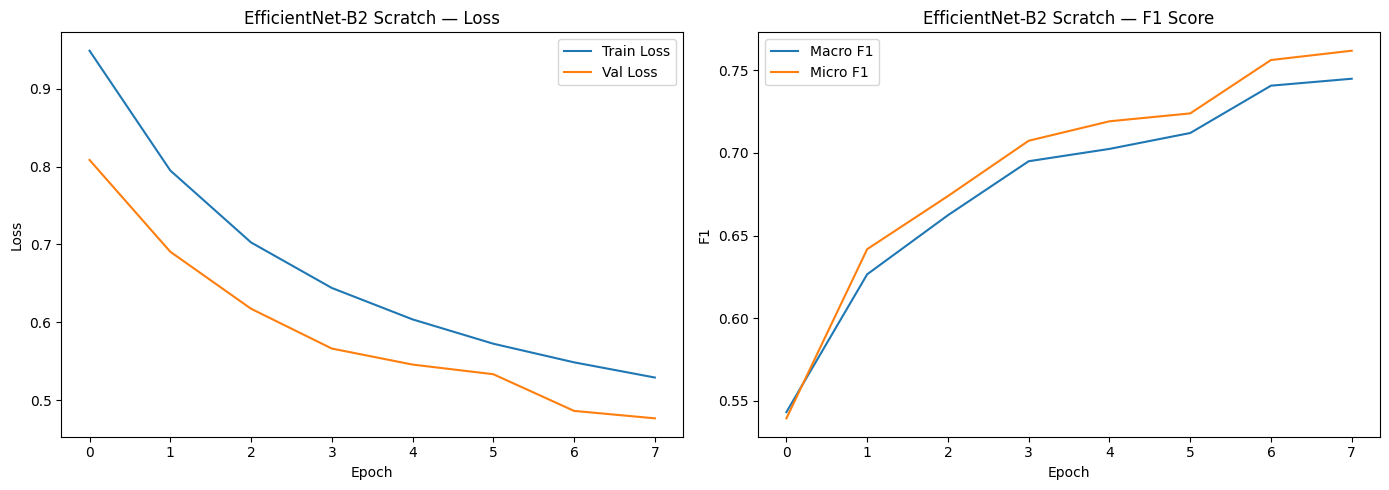

In [15]:
plot_history(history_scratch, 'EfficientNet-B2 Scratch')


===== EfficientNet-B2 Scratch — Validation Evaluation =====


Evaluating EfficientNet-B2 Scratch: 100%|██████████| 1484/1484 [01:30<00:00, 16.38it/s]



===== Per-Class Metrics — EfficientNet-B2 Scratch =====

Class: 0
  Precision: 0.8521
  Recall   : 0.8082
  F1-score : 0.8295
  AUC      : 0.9127

Class: 1
  Precision: 0.8296
  Recall   : 0.9025
  F1-score : 0.8645
  AUC      : 0.9583

Class: 2
  Precision: 0.5712
  Recall   : 0.8231
  F1-score : 0.6744
  AUC      : 0.9350

Class: 3
  Precision: 0.5082
  Recall   : 0.9050
  F1-score : 0.6509
  AUC      : 0.8959

Class: 4
  Precision: 0.5737
  Recall   : 0.9161
  F1-score : 0.7055
  AUC      : 0.9199

===== Overall Metrics — EfficientNet-B2 Scratch =====
  Macro F1  : 0.7450
  Micro F1  : 0.7619
  Macro AUC : 0.9244


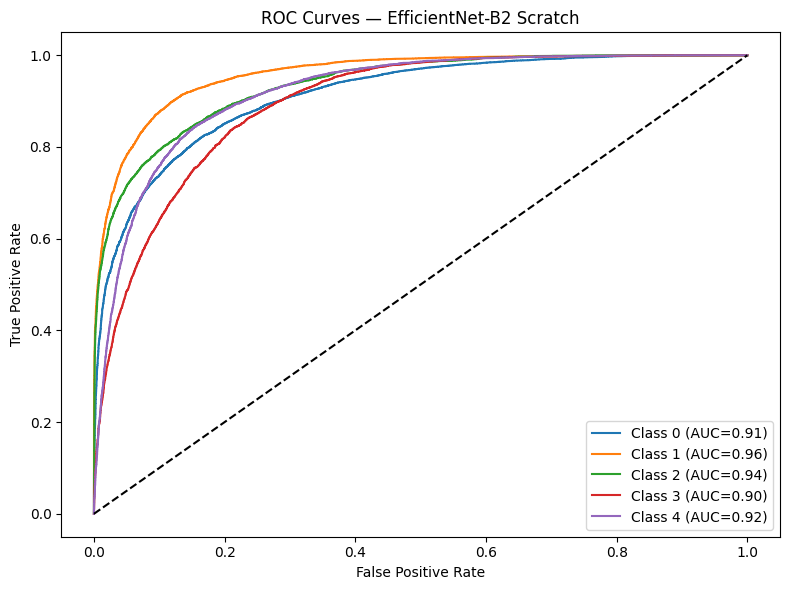

Final — Macro F1: 0.7450  |  Micro F1: 0.7619


In [16]:
print('\n===== EfficientNet-B2 Scratch — Validation Evaluation =====')
macro_f1_sc, micro_f1_sc = evaluate_model(
    model_scratch, val_loader,
    title='EfficientNet-B2 Scratch'
)
print(f'Final — Macro F1: {macro_f1_sc:.4f}  |  Micro F1: {micro_f1_sc:.4f}')

---
# ▶ TRAINING 3 of 3 — Transfer Learning (frozen backbone)

- Pretrained ImageNet weights
- **Backbone frozen** — only the classifier head trains
- LR = 1e-4
- Mixed precision enabled

In [17]:
# ===============================
#  Transfer Learning
# ===============================

TRANSFER_SAVE = '/kaggle/working/efficientnet_b2_best_transfer.pth'

print('--- Building EfficientNet-B2 (transfer) ---')
model_transfer = build_efficientnet_b2('transfer')

print(f'--- Training (transfer) for {EPOCHS} epochs ---')
model_transfer, history_transfer = train_model(
    model_transfer,
    strategy_label='transfer',
    save_path=TRANSFER_SAVE,
    use_amp=True
)

--- Building EfficientNet-B2 (transfer) ---
  EfficientNet-B2 [transfer] — trainable params: 7,045 / 7,708,039
--- Training (transfer) for 8 epochs ---


[transfer] Epoch 1/8: 100%|██████████| 9011/9011 [12:47<00:00, 11.74it/s]



Epoch [1/8]
  Train Loss : 0.9539
  Val   Loss : 0.8700
  Macro F1   : 0.5353   Micro F1: 0.5299
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_transfer.pth  (Macro F1 = 0.5353)


[transfer] Epoch 2/8: 100%|██████████| 9011/9011 [12:49<00:00, 11.72it/s]



Epoch [2/8]
  Train Loss : 0.8913
  Val   Loss : 0.8224
  Macro F1   : 0.5694   Micro F1: 0.5737
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_transfer.pth  (Macro F1 = 0.5694)


...


Epoch [6/8]
  Train Loss : 0.8262
  Val   Loss : 0.7659
  Macro F1   : 0.5908   Micro F1: 0.5981


[transfer] Epoch 7/8: 100%|██████████| 9011/9011 [12:43<00:00, 11.80it/s]



Epoch [7/8]
  Train Loss : 0.8199
  Val   Loss : 0.7603
  Macro F1   : 0.5957   Micro F1: 0.6054
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_transfer.pth  (Macro F1 = 0.5957)


[transfer] Epoch 8/8: 100%|██████████| 9011/9011 [12:37<00:00, 11.89it/s]



Epoch [8/8]
  Train Loss : 0.8158
  Val   Loss : 0.7515
  Macro F1   : 0.5982   Micro F1: 0.6085
  ✅ Best model saved → /kaggle/working/efficientnet_b2_best_transfer.pth  (Macro F1 = 0.5982)

Training complete [transfer]. Best Macro F1: 0.5982


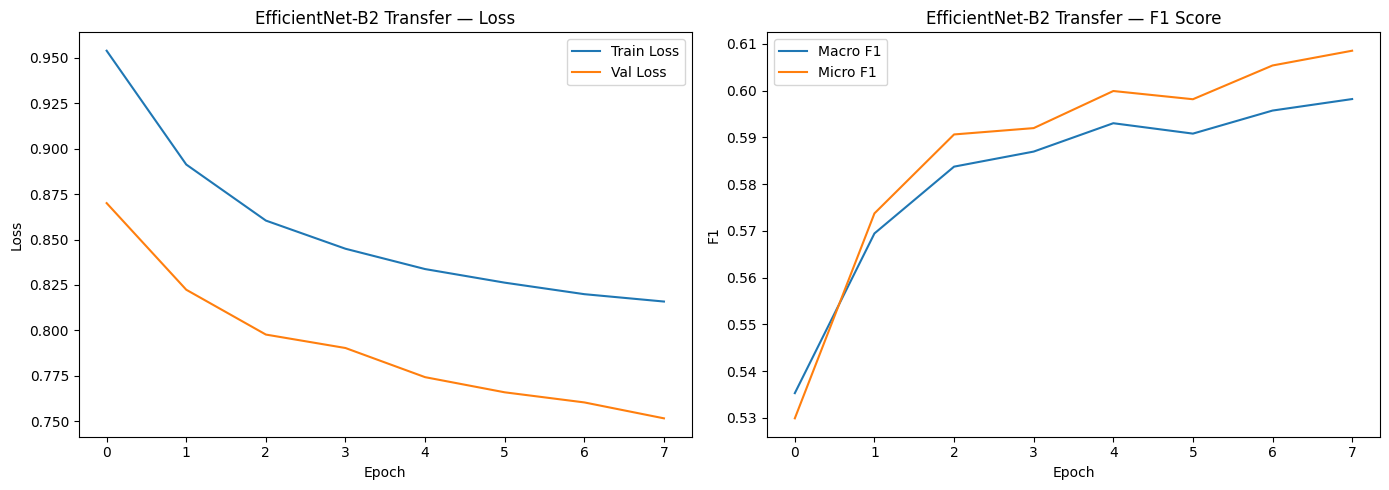

In [18]:
plot_history(history_transfer, 'EfficientNet-B2 Transfer')


===== EfficientNet-B2 Transfer — Validation Evaluation =====


Evaluating EfficientNet-B2 Transfer: 100%|██████████| 1484/1484 [01:30<00:00, 16.39it/s]



===== Per-Class Metrics — EfficientNet-B2 Transfer =====

Class: 0
  Precision: 0.7419
  Recall   : 0.6512
  F1-score : 0.6936
  AUC      : 0.7726

Class: 1
  Precision: 0.6993
  Recall   : 0.7586
  F1-score : 0.7277
  AUC      : 0.8552

Class: 2
  Precision: 0.3057
  Recall   : 0.8147
  F1-score : 0.4445
  AUC      : 0.7920

Class: 3
  Precision: 0.3653
  Recall   : 0.8769
  F1-score : 0.5158
  AUC      : 0.7686

Class: 4
  Precision: 0.4639
  Recall   : 0.8872
  F1-score : 0.6092
  AUC      : 0.8452

===== Overall Metrics — EfficientNet-B2 Transfer =====
  Macro F1  : 0.5982
  Micro F1  : 0.6085
  Macro AUC : 0.8067


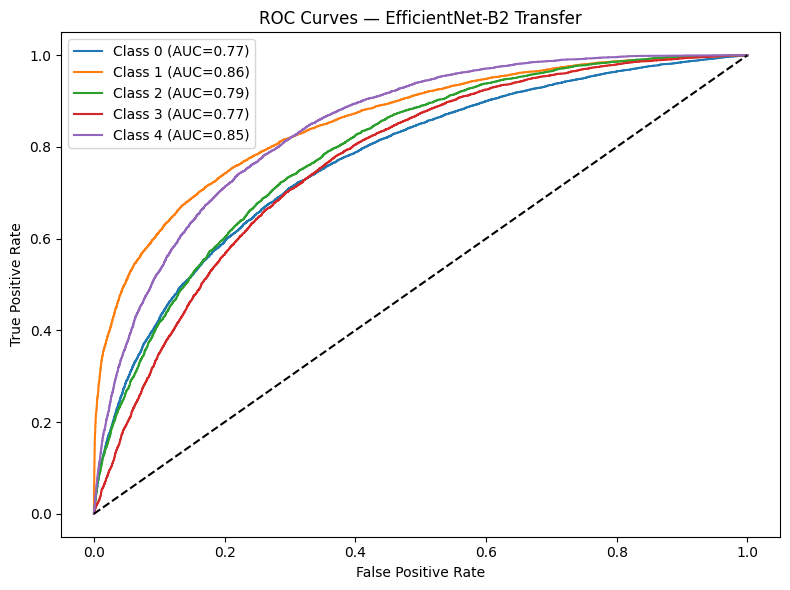

Final — Macro F1: 0.5982  |  Micro F1: 0.6085


In [19]:
print('\n===== EfficientNet-B2 Transfer — Validation Evaluation =====')
macro_f1_tr, micro_f1_tr = evaluate_model(
    model_transfer, val_loader,
    title='EfficientNet-B2 Transfer'
)
print(f'Final — Macro F1: {macro_f1_tr:.4f}  |  Micro F1: {micro_f1_tr:.4f}')

---
## Final Model Comparison

In [20]:
# ===============================
#  Final Comparison Table
# ===============================

print('\n' + '='*55)
print('   Final Comparison — EfficientNet-B2')
print('='*55)
print(f'{"Model":<30}{"Macro F1":<12}{"Micro F1"}')
print('-'*55)
print(f'{"EfficientNet-B2 Fine-Tune":<30}{macro_f1_ft:.4f}      {micro_f1_ft:.4f}')
print(f'{"EfficientNet-B2 Scratch":<30}{macro_f1_sc:.4f}      {micro_f1_sc:.4f}')
print(f'{"EfficientNet-B2 Transfer":<30}{macro_f1_tr:.4f}      {micro_f1_tr:.4f}')
print('='*55)

best_strategy = max(
    [('Fine-Tune', macro_f1_ft), ('Scratch', macro_f1_sc), ('Transfer', macro_f1_tr)],
    key=lambda x: x[1]
)
print(f'\n🏆 Best strategy: {best_strategy[0]} (Macro F1 = {best_strategy[1]:.4f})')


   Final Comparison — EfficientNet-B2
Model                         Macro F1    Micro F1
-------------------------------------------------------
EfficientNet-B2 Fine-Tune     0.8485      0.8639
EfficientNet-B2 Scratch       0.7450      0.7619
EfficientNet-B2 Transfer      0.5982      0.6085

🏆 Best strategy: Fine-Tune (Macro F1 = 0.8485)


In [21]:
# ===============================
#  Verify Saved Checkpoints
# ===============================

print('Saved model files in /kaggle/working/:')
for fname in sorted(os.listdir('/kaggle/working/')):
    if fname.startswith('efficientnet_b2'):
        fpath = os.path.join('/kaggle/working/', fname)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {fname}  ({size_mb:.1f} MB)')

Saved model files in /kaggle/working/:
  efficientnet_b2_best_finetune.pth  (29.8 MB)
  efficientnet_b2_best_scratch.pth  (29.8 MB)
  efficientnet_b2_best_transfer.pth  (29.8 MB)


---
## How to Reload a Saved Model After Session Restart

If your Kaggle session restarts, reload any checkpoint like this:

```python
import torch
import torchvision.models as models
import torch.nn as nn

NUM_CLASSES = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rebuild architecture
model = models.efficientnet_b2(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

# Load saved weights  (change filename as needed)
CHECKPOINT = '/kaggle/working/efficientnet_b2_best_finetune.pth'
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print('Model loaded from', CHECKPOINT)
```